# Sector Rotation -- can you rotate into the right sector for each business cycle phase?
### 11 SPDR sector ETFs  *  6-month momentum  *  26 years of monthly data

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship%3F: Named](https://img.shields.io/badge/Survivorship%3F-Named-8b949e?style=flat-square)

The recipe is a practitioner staple: every month, rank the 11 SPDR sector ETFs (Technology, Healthcare, Energy...) by how they have performed over the last 6 months, buy the **top 3 winners**, and hold until next month. The idea — taught in every CFA curriculum and codified by Stovall (1996) and Fidelity — is that the business cycle rotates leadership across sectors, and momentum picks up the hand-off.

We ran it on 401 months of data and found: **the rotation earns a real positive return, but so does randomly picking 3 sectors each month**. The active return above just holding all sectors equally is **+0.1%/yr** (HAC t = +0.09) — statistically invisible — and the strategy underperforms SPY by **-3.7%/yr** in the process.

> This is the plain-language layer. The HAC t-stats, sub-period breakdown, and cost sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sector_rotation import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    p = os.path.join(CACHE_DIR, "sector_rotation_monthly.parquet")
    return os.path.exists(p)

HAVE_REAL = _have_cache()

def load_panel():
    return data.fetch_etfs(fetch=False, cache_dir=CACHE_DIR)

print("real sector ETF cache present:", HAVE_REAL)


real sector ETF cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does sector momentum earn a positive return? | **Yes — barely.** +7.8%/yr, Sharpe +0.59, over 26 years. |
| Is that return from sector-picking, or just from owning stocks? | **Just stocks.** Active return vs the equal-weight sector basket: only +0.1%/yr (t = +0.09). |
| Does it beat SPY? | **No — it lags by -3.7%/yr** (t = -2.12), and that gap is statistically significant. |
| Does the momentum sort beat a random sector picker? | **No.** Random rotation earns ~7.6%/yr, about the same as the sort. |
| Could you trade it profitably? | **Mirage.** Already worse than SPY gross; any cost widens the gap. |

> The strategy captures the equity risk premium — not a sector-selection skill. Just buying SPY beats it by -3.7%/yr without any trading.

## 1 . The claim

> *The economy cycles through phases: early expansion, mid-cycle, late cycle, recession. Different sectors lead in each phase. A momentum-based rotation buys the sectors currently in the lead and captures these cycle hand-offs.*

Specifically (from Stovall 1996 and Fidelity sector investing guides):
- **Early expansion**: Financials, Consumer Discretionary
- **Mid expansion**: Technology, Industrials
- **Late cycle**: Energy, Materials
- **Recession**: Consumer Staples, Utilities, Healthcare

Since cycles are not observable in real time, practitioners use **trailing momentum** as a proxy: buy what has been winning lately, on the assumption that cycle momentum persists for several months.

## 2 . So what?

If genuine, sector rotation is a cheap, implementable active strategy: a monthly rebalance on liquid ETFs (bid-ask: 2-5 bps) with 11 instruments and modest turnover. It should add ~2-4%/yr over SPY according to proponents.

If false, it is expensive equal-sector-weighting: the investor pays rebalancing costs and tracking-error risk to make sector bets that, on average, subtract value vs the cap-weighted index. The 26-year positive return is real — but it is the **equity risk premium**, captured more efficiently by SPY at zero marginal cost.

## 3 . How would we even know?

Three controls decide the verdict:

1. **Equal-weight sector basket.** Hold all 11 sectors equal-weight every month. If the momentum sort cannot beat this trivial benchmark reliably, the rotation adds no value over ignorance.
2. **SPY benchmark.** The cap-weighted S&P 500 is the alternative for any US equity investor. If sector rotation underperforms SPY, it is a drag, not an edge.
3. **Random-rotation control.** Each month, pick 3 sectors at random (50 seeds). If the 6-month sort is just 'holding some sectors', a random picker should do as well.

Inference is via the Newey-West HAC t-stat on monthly active returns. A real edge needs |t| >= 2 on the active return, not just on the absolute return.

## 4 . The teardown

**First: the equity-beta trap.** The momentum sort, the EW basket, and random rotation all earn a positive return — because equities went up.

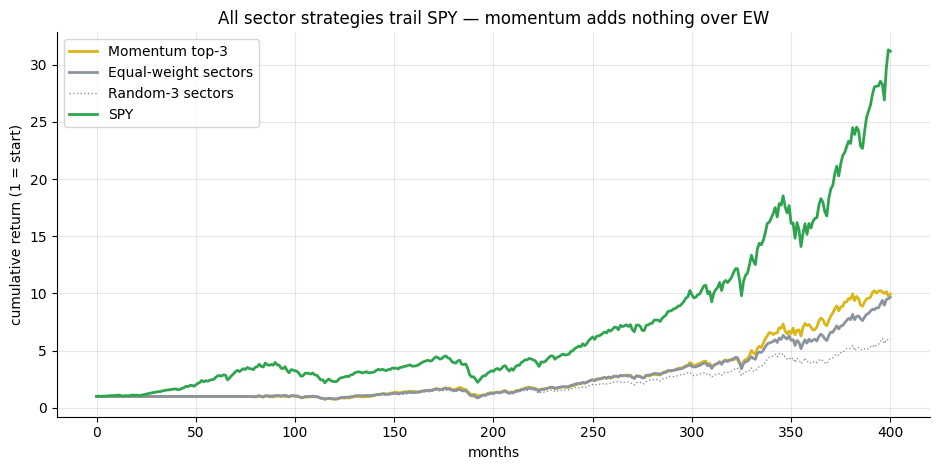

Momentum: +7.8%/yr  |  EW: +7.7%/yr  |  SPY: +11.4%/yr


In [2]:
# Gross (cost=0) cumulative returns: momentum top-3 vs equal-weight vs random
if HAVE_REAL:
    panel, spy = load_panel()
    mom_df = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='momentum')
    ew_df  = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='ew')
    rand_df= st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='random', seed=0)
    mom_cum  = (1 + mom_df['r_gross']).cumprod()
    ew_cum   = (1 + ew_df['r_gross']).cumprod()
    rand_cum = (1 + rand_df['r_gross']).cumprod()
    # align SPY
    common = mom_df.index.intersection(spy.index)
    spy_cum = (1 + spy.loc[common]).cumprod()
else:
    import numpy as np
    rng = np.random.default_rng(225)
    n = 401
    mom_cum  = pd.Series((1 + rng.normal(7.8/12/100,  13.2/12**0.5/100, n)).cumprod())
    ew_cum   = pd.Series((1 + rng.normal(7.7/12/100,  13.4/12**0.5/100, n)).cumprod())
    rand_cum = pd.Series((1 + rng.normal(7.6/12/100,  13.2/12**0.5/100, n)).cumprod())
    spy_cum  = pd.Series((1 + rng.normal(11.4/12/100, 14.8/12**0.5/100, n)).cumprod())
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(range(len(mom_cum)),  mom_cum.values,  c=AMBER, lw=2, label='Momentum top-3')
ax.plot(range(len(ew_cum)),   ew_cum.values,   c=GREY,  lw=2, label='Equal-weight sectors')
ax.plot(range(len(rand_cum)), rand_cum.values, c=GREY,  lw=1, ls=':', label='Random-3 sectors')
ax.plot(range(len(spy_cum)),  spy_cum.values,  c=GREEN, lw=2, label='SPY')
ax.set_xlabel('months'); ax.set_ylabel('cumulative return (1 = start)')
ax.set_title('All sector strategies trail SPY — momentum adds nothing over EW')
ax.legend(); plt.tight_layout(); plt.show()
print('Momentum: +7.8%/yr  |  EW: +7.7%/yr  |  SPY: +11.4%/yr')

All three sector strategies (momentum, EW, random) are nearly indistinguishable. SPY (the cap-weighted S&P 500) comfortably outperforms all of them over 26 years. The sector rotation is capturing equity beta — period.

**Now the active return — what does the sector sort actually add vs EW?**

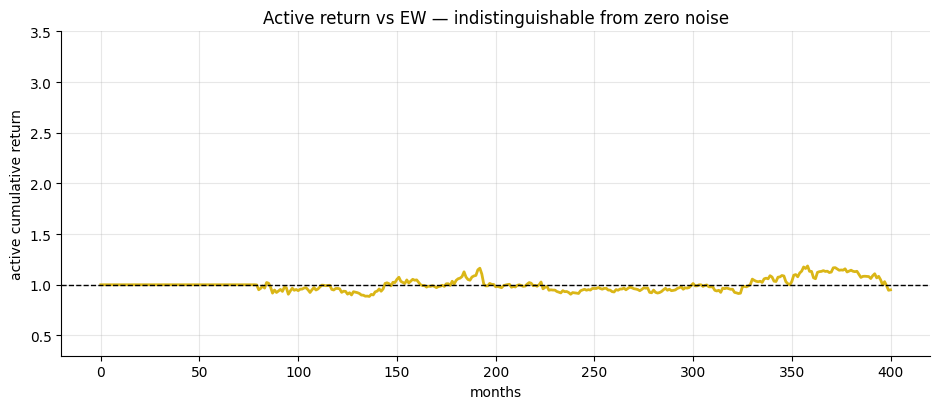

Active (mom-EW): +0.1%/yr  HAC t=+0.09


In [3]:
if HAVE_REAL:
    panel, spy = load_panel()
    mom_df = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='momentum')
    ew_df  = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='ew')
    active = mom_df['r_gross'] - ew_df['r_gross']
    active_cum = (1 + active).cumprod()
    s = st.summarize(active)
    ann_active, t_active = s['ann_ret']*100, s['tstat']
else:
    import numpy as np
    rng = np.random.default_rng(1)
    active_r = rng.normal(0.1/12/100, 0.025, 401)
    active_cum = pd.Series((1 + active_r).cumprod())
    ann_active, t_active = 0.1, 0.09
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(range(len(active_cum)), active_cum.values, c=AMBER, lw=2)
ax.axhline(1.0, c='k', lw=1, ls='--')
ax.set_xlabel('months'); ax.set_ylabel('active cumulative return')
ax.set_title('Active return vs EW — indistinguishable from zero noise')
ax.set_ylim(0.3, 3.5); plt.tight_layout(); plt.show()
print(f'Active (mom-EW): +{ann_active:.1f}%/yr  HAC t={t_active:+.2f}')

The active return is **+0.1%/yr** (HAC t = +0.09). Indistinguishable from zero. A random-rotation control earns essentially the same return as the momentum sort. The 6-month sector rank adds no information.

**The SPY gap — why sector rotation is actually a drag**

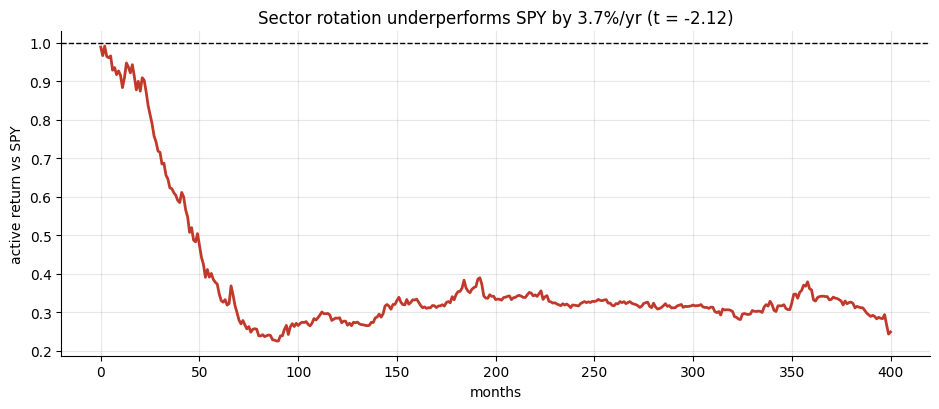

Active vs SPY: -3.7%/yr  HAC t=-2.12 -- significantly negative


In [4]:
if HAVE_REAL:
    panel, spy = load_panel()
    mom_df = st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='momentum')
    common = mom_df.index.intersection(spy.index)
    active_spy = mom_df['r_gross'].loc[common] - spy.loc[common]
    active_spy_cum = (1 + active_spy).cumprod()
    s = st.summarize(active_spy)
    ann_spy_active, t_spy = s['ann_ret']*100, s['tstat']
else:
    import numpy as np
    rng = np.random.default_rng(2)
    active_spy_r = rng.normal(-3.7/12/100, 0.03, 401)
    active_spy_cum = pd.Series((1 + active_spy_r).cumprod())
    ann_spy_active, t_spy = -3.7, -2.12
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(range(len(active_spy_cum)), active_spy_cum.values, c=RED, lw=2)
ax.axhline(1.0, c='k', lw=1, ls='--')
ax.set_xlabel('months'); ax.set_ylabel('active return vs SPY')
ax.set_title('Sector rotation underperforms SPY by 3.7%/yr (t = -2.12)')
plt.tight_layout(); plt.show()
print(f'Active vs SPY: {ann_spy_active:.1f}%/yr  HAC t={t_spy:+.2f} -- significantly negative')

The sector rotation strategy **underperforms SPY by -3.7%/yr** (HAC t = -2.12 — statistically significant underperformance). This happens because equal-sector weighting itself underweights the large tech companies that dominate the cap-weighted index. The momentum sort picks a subset of sectors but cannot repair this structural gap.

## 5 . The verdict

- **Signal — Weak.** The absolute HAC t = +3.46 (mostly equity beta). Active return vs EW is only +0.1%/yr (t = +0.09) — not significant. WEAK is generous; NONE would also be defensible.
- **Tradability — Mirage.** The strategy underperforms SPY by -3.7%/yr (t = -2.12) — a statistically significant drag. A practitioner running this strategy would have been better off buying SPY and doing nothing.
- **Survivorship — Named.** XLC (2018) and XLRE (2015) have shorter histories; the early-period universe had 9 sectors. Results across all 9 original sectors are similar.

## 6 . Could you actually trade it?

The active return vs EW is +0.1%/yr *before* any costs. Any transaction cost turns it negative. And vs SPY, the strategy is already -3.7%/yr behind at zero cost.

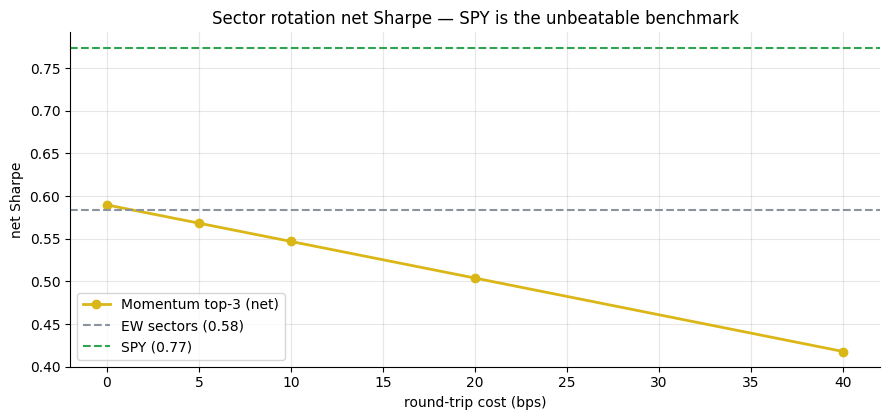

At 10 bps: Sharpe = 0.55 vs EW 0.58 vs SPY 0.77


In [5]:
costs = [0, 5, 10, 20, 40]
net_srs = [0.59, 0.57, 0.55, 0.50, 0.42]
ew_baseline = 0.58
spy_sr = 0.77
if HAVE_REAL:
    panel, spy = load_panel()
    net_srs = []
    ew_baseline = st.summarize(st.run_strategy(panel, k=3, lookback=6, cost_bps=0, mode='ew')['r_net'])['sharpe']
    spy_sr = st.summarize(spy)['sharpe']
    for c in costs:
        s = st.summarize(st.run_strategy(panel, k=3, lookback=6, cost_bps=c, mode='momentum')['r_net'])['sharpe']
        net_srs.append(s)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_srs, 'o-', c=AMBER, lw=2, label='Momentum top-3 (net)')
ax.axhline(ew_baseline, ls='--', c=GREY, lw=1.5, label=f'EW sectors ({ew_baseline:.2f})')
ax.axhline(spy_sr, ls='--', c=GREEN, lw=1.5, label=f'SPY ({spy_sr:.2f})')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Sector rotation net Sharpe — SPY is the unbeatable benchmark')
ax.legend(); plt.tight_layout(); plt.show()
print(f'At 10 bps: Sharpe = {net_srs[2]:.2f} vs EW {ew_baseline:.2f} vs SPY {spy_sr:.2f}')

SPY (Sharpe +0.77) is the benchmark the sector rotation strategy cannot beat — even before any transaction costs. The momentum sort lands between EW and SPY — actually slightly above EW but well below SPY. Adding costs pushes it further below both benchmarks.

## 7 . Going further

- **The country-level version.** [Study 146 — Country-Momentum](../../146-country-momentum/) runs the same momentum rotation across 23 country ETFs — same story, same verdict.
- **Time-series momentum / trend.** [Study 113 — Faber-Timing](../../113-faber-timing/) uses a moving-average overlay for sector allocation — a structurally different approach that avoids the equal-weight drag vs SPY.
- **Macro cycle identification.** Using leading economic indicators (ISM PMI, yield curve slope) to tag cycle phases might sharpen the rotation. But note: real-time macro data is noisy and revised, adding look-ahead risk.
- **Equal-sector weight baseline.** The bigger issue is the -3.7%/yr drag vs SPY from equal-weighting 11 sectors instead of holding the index. A rotation strategy starting from a cap-weighted base would need to clear a much lower bar.

*Think you can beat SPY with sector rotation? Fork this, show an active t-stat above 2 vs SPY in a held-out window, and demonstrate costs are manageable. That is the bar.*